In [31]:
import pandas as pd

# Load CSV
df = pd.read_csv('house_prices.csv')  # Replace with your file path
print(f"Original rows: {df.shape[0]}")
print(df[['price', 'bedrooms']].head())

Original rows: 4140
      price  bedrooms
0  376000.0       3.0
1  800000.0       4.0
2 2238888.0       5.0
3  324000.0       3.0
4  549900.0       5.0


In [2]:
# Format price
pd.options.display.float_format = '{:.1f}'.format


In [45]:
# Remove duplicates
df_clean = df.drop_duplicates(keep='first')
print(f"Non-duplicate rows: {df_clean.shape[0]}")

Non-duplicate rows: 4140


In [33]:
# Filter bedrooms = 3, 4, or 5
filtered_df = df_clean[df_clean['bedrooms'].isin([3, 4, 5])]
print(f"Rows with 3, 4, or 5 bedrooms: {filtered_df.shape[0]}")

Rows with 3, 4, or 5 bedrooms: 3532


In [34]:
# Calculate min, max, average price
min_price = filtered_df['price'].min()
max_price = filtered_df['price'].max()
avg_price = filtered_df['price'].mean()
print(f"Minimum Price: {min_price:.1f}")
print(f"Maximum Price: {max_price:.1f}")
print(f"Average Price: {avg_price:.1f}")

Minimum Price: 0.0
Maximum Price: 26590000.0
Average Price: 574008.4


In [35]:
# Filter top 3 most expensive houses per bedroom count
top_expensive = filtered_df.groupby('bedrooms').apply(
    lambda x: x.nlargest(3, 'price')[['price', 'bedrooms']]
).reset_index(drop=True)
print("\nTop 3 Most Expensive Houses per Bedroom Count:")
print(top_expensive)


Top 3 Most Expensive Houses per Bedroom Count:
       price  bedrooms
0 26590000.0       3.0
1 12899000.0       3.0
2  2560498.3       3.0
3  4489000.0       4.0
4  3710000.0       4.0
5  3000000.0       4.0
6  7062500.0       5.0
7  4668000.0       5.0
8  3800000.0       5.0


C:\Users\Rami\AppData\Local\Temp\ipykernel_25228\2985596711.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_expensive = filtered_df.groupby('bedrooms').apply(


In [36]:
# Save results
top_expensive.to_csv('top_expensive_houses.csv', index=False)
# Insight: Analyzed X houses with 3-5 bedrooms, found top 3 expensive per group.

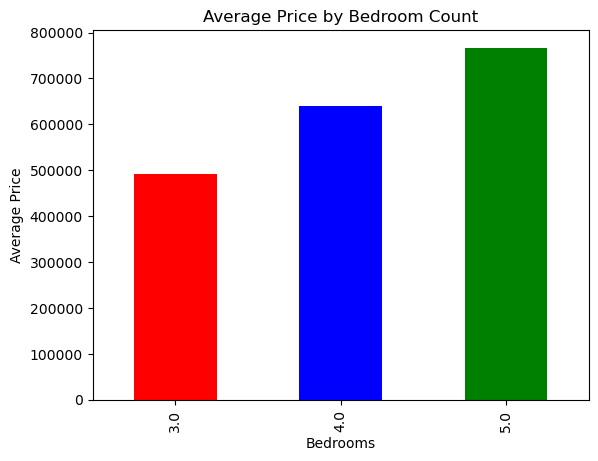

In [42]:
import matplotlib.pyplot as plt
avg_prices = filtered_df.groupby('bedrooms')['price'].mean()
avg_prices.plot(kind='bar', xlabel='Bedrooms', ylabel='Average Price', title='Average Price by Bedroom Count', color=['red','blue','green'])
# Save plot
plt.savefig('avg_price_by_bedrooms.png')